# Attention

`ScaledDot-Product Attention` and `MultiheadAttention` was published in 2017 in the NeurIPS paper [Attention is All You Need](https://arxiv.org/abs/1706.03762) by Google Brain. It is a key component of the Transformer and has gained widespread attention (no pun intended) in diverse architectures ranging from computer vision to natural language processing and bioinformatics. 

## ScaledDot-Product Attention

The attention function is described as answering a query $q_t$ with a key-value pair $k_t$, $v_t$ and subsequently mapping them to an output $o_t$ for the $t$-th token. The output $o_t$ is a weighted sum of $v_t$ where the weight is a *compatibility* function between the query and respective key. 

<img src="../images/architecture.png" alt="drawing" width="600"/>


## Computation


Take the sentence "The dog jumped over the box". These are tokenized to become [$x_{the}$, $x_{dog}$, ... ,   $x_{box}$], where $x_t \in \mathbb{R}^d$

1. **Make query** $q_t$, by linear transformation with $W^{Q} \in \mathbb{R}^{d_{model} \times d_k}$ which is learned during training, and $d_k$ is the dimension of query/key/value vectors and $d_{model}$ is the dimension of the input token embeddings as well as the hidden states throughout the model. The resulting query is 
$$q_t = W^Q x_t$$

2. **Make keys and values** with $W^K \in \mathbb{R}^{d_{model} \times d_k}$ and $W^V \in \mathbb{R}^{d_{model} \times d_v}$ respectively. 

$$k_t = W^K x_t \text{ and } v_t = W^V x_t$$

3. **Compute the amount of attention token $t$ pays to each other token**. Denote the *amount* of attention paid by $\text{score}_i$ for each other token $t \in \{1, 2, ... T\}$ where $i$ is the number of tokens. The score is computed as $$\text{score}_i = q_t \cdot k_i \text{ for each } i,$$ and represents the compatibility between the question $q_t$ and the summary $k_i$ of information between token $t$ and $i$.

4. **Calculate the weighted sum** $o_t$ for each token $t$ as $$o_t = \sum_i^{T} \text{softmax}(q_t \cdot k_i) \cdot v_i,$$ where $t \in \{1, 2, ... , T\}$ and $T$ is the total number of tokens in a sequence. 

Above the queries, keys, and values are elements in terms of $t$, however, for practical purposes they are represented as matrices. 
- The queries form the query matrix $Q \in \mathbb{R}^{T \times d_k}$
- The keys form the key matrix $K \in \mathbb{R}^{T \times d_k}$
- The values form the value matrix $V \in \mathbb{R}^{T \times d_v}$
- The output is the attention matrix $O \in \mathbb{R}^{T \times d_v}$
- The input tokens are represented as a matrix $X \in \mathbb{R}^{T \times d_{model}}$

The computation described above remains the same conceptually, but is now represented in matrix form. The attention function can be expressed as:

$$O = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

where $O$ is the output matrix, $Q$ is the query matrix, $K$ is the key matrix, and $V$ is the value matrix. The scaling factor $\sqrt{d_k}$ is used to prevent the dot product from growing too large and causing numerical instability. The softmax function is applied to the dot product of the query and key matrices to obtain the attention weights, which are then multiplied by the value matrix to obtain the final output.

<img src="../images/attention.png" alt="attention" width="1200"/>


## Hyperparameters and Tokenization

The example sentence "The dog jumped over the box" is chosen. $d_{model}$ is set to 16 and $d_k$ is set to 8 (in code as $\lfloor d_{model} \rfloor$). The words are tokenized


In [1]:
sentence = "The dog jumped over the box"
# Create a vocabulary and map tokens to indices
tokens = sentence.lower().split()
T = len(tokens)

d_model = 16
d_k = d_model // 2 

In [2]:
import torch
import torch.nn.functional as F

def tokenizer(sentence):
    tokens = sentence.lower().split() # Separate the sentence into individual words

    # Make a HashMap of words (NOTE: HashMap in Python makes a set which has only unique words) 
    vocab = {word: idx for idx, word in enumerate(set(tokens))} 

    # Create a list of indices for each token in the sentence
    token_indices = [vocab[token] for token in tokens]

    # Convert the list of indices to a PyTorch tensor as 64 bit integers (long)
    tokens_tensor = torch.tensor(token_indices, dtype=torch.long)
    return tokens_tensor, vocab

In [3]:
print("d_model:", d_model)
print("d_k:", d_k)
print("sentence:", sentence)
print("tokens:", tokens)
print("T:", T)
print("Token tensor:", tokenizer(sentence)[0])
print("Vocabulary:", tokenizer(sentence)[1])

d_model: 16
d_k: 8
sentence: The dog jumped over the box
tokens: ['the', 'dog', 'jumped', 'over', 'the', 'box']
T: 6
Token tensor: tensor([1, 3, 2, 4, 1, 0])
Vocabulary: {'box': 0, 'the': 1, 'jumped': 2, 'dog': 3, 'over': 4}


## Embedding Layer

The purpose of this is to convert the input tokens into a dense vector representation. The embedding layer is a lookup table that maps each token to a vector of fixed size. It is typically initialized with random weights and trained along with the rest of the model.

In this implementation, `nn.Embedding` class from PyTorch is used to initialize the embedding layer with a dictionary of 10 and 3 dimensions.

In [4]:
vocab_size = len(tokenizer(sentence)[1])
embedding_dim = d_model

print("Vocabulary size:", vocab_size)
print("Embedding dimension:", embedding_dim)

Vocabulary size: 5
Embedding dimension: 16


In [5]:
# The embedding layer is initialized with 10 words and 3 dimensions
# The embedding layer is initialized with random weights
embedding = torch.nn.Embedding(vocab_size, embedding_dim)
X = embedding(tokenizer(sentence)[0])
print("Embeddings shape:", X.shape)

Embeddings shape: torch.Size([6, 16])


# ScaledDot-Product Attention

The matrices $W^Q$, $W^K$, and $W^V$ are initialized with random weights to be of size $d_{model} \times d_k$.

In [6]:
W_q = torch.randn(d_model, d_k)
W_k = torch.randn(d_model, d_k)
W_v = torch.randn(d_model, d_k)

print("Shape of W_q, W_k, and W_v: ", W_q.shape, W_k.shape, W_v.shape)

Shape of W_q, W_k, and W_v:  torch.Size([16, 8]) torch.Size([16, 8]) torch.Size([16, 8])


Once the weights are initialized, the query, key, and value matrices are computed by multiplying the input token embeddings with the respective weight matrices. The following cell implements the computation 

$$ Q = XW^Q, K = XW^K, V = XW^V. $$


In [7]:
Q = X @ W_q
K = X @ W_k
V = X @ W_v

print("Shape of Q, K, and V : ", Q.shape, K.shape, V.shape)

Shape of Q, K, and V :  torch.Size([6, 8]) torch.Size([6, 8]) torch.Size([6, 8])


Subsequently, the attention scores $O$ are computed using the formula

$$ O = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V $$

In [8]:
scores = Q @ K.T / torch.sqrt( torch.tensor(d_k) )
attention_probabilities = F.softmax(scores, dim=1)
O = attention_probabilities @ V
print("Shape of attention probabilities: ", attention_probabilities.shape)
print("Shape of scores: ", scores.shape)
print("Shape of O: ", O.shape)

Shape of attention probabilities:  torch.Size([6, 6])
Shape of scores:  torch.Size([6, 6])
Shape of O:  torch.Size([6, 8])


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

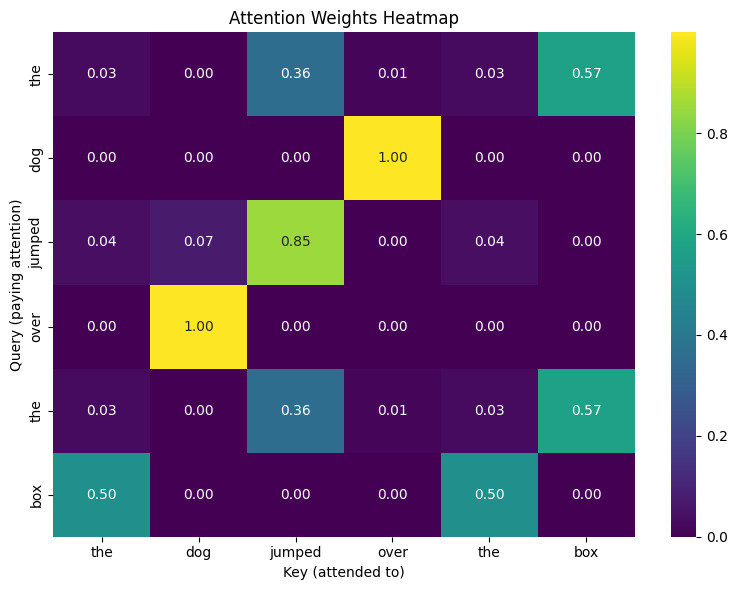

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(attention_probabilities.detach().numpy(), xticklabels=tokens, yticklabels=tokens,
            cmap="viridis", annot=True, fmt=".2f")
plt.title("Attention Weights Heatmap")
plt.xlabel("Key (attended to)")
plt.ylabel("Query (paying attention)")
plt.tight_layout()
plt.show()

The heatmap looks odd because the matrices were initialized with random weights.

## Interpretations and Intuition

**Interpretations** of each value
- $q_t$ is the query vector for the $t$-th token. It represents the information that token $t$ is *looking* for.
- $k_t$ is the key vector for the $t$-th token and represents what this token $contains$ or can what it can $answer$ to.
- $v_t$ is the value vector for the $t$-th token and it has the relevant information that the key unlocks if the query deems this token relevant

**Example**

E.g., in the sentence "the dog jumped over the box" the query $q_{jumped}$ pulls information from the key-value pairs of "dog" and "box" the most because "jumped" is trying to understand *who* jumped and *to where*. $q_{jumped}$ is the question "jumped" is asking, $k_{jumped}$ is the reference point, and $v_{jumped}$ is what "jumped" contributes if chosen. 


**Intuition/rule of thumb**
- Query: What am I looking for?
- Key: What do I have to answer queries? (Summary of information in value).
- Value: What do I share if my knowledge is to be unlocked?

The last step (4.) should enforce the intuition. The softmax function

$$ \text{softmax}(x_i) = \frac{e^{x_i}}{\sum_{j=1}^{T} e^{x_j}} $$

normalizes a vector and transforms it into a probability distribution, e.g., 

$$ \text{softmax}([1, 2, 3]) = [0.09003057, 0.66524096, 0.24472847] $$

So, when softmax is computed over $q_t \cdot k_i$, it is encompassing the probability of each token $i$ being relevant to the query $q_t$. The weighted sum of the values $v_i$ is then a summary of the information that is relevant to the query $q_t$. **The weighted sum is thus the value of each token $i$ multiplied by the probability of it being relevant to the query $q_t$.**